In [126]:
#https://github.com/sunnysavita10/yt-live-crash-course/blob/main/notebook/test.ipynb
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
#below line of code will be used to ignore error 
import warnings
warnings.filterwarnings("ignore", message="Core Pydantic V1 functionality isn't compatible")

load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

if not OPENROUTER_API_KEY:
    raise ValueError("Missing API key")

# ✅ Set env for LangChain
os.environ["OPENAI_API_KEY"] = OPENROUTER_API_KEY
os.environ["OPENAI_BASE_URL"] = "https://openrouter.ai/api/v1"

chat_llm = ChatOpenAI(
    model="openai/gpt-3.5-turbo"
)

response = chat_llm.invoke("Hello, how are you?")
print(response.content)

Hello! I'm just a computer program, so I don't have feelings, but I'm here to help you. How can I assist you today?


In [127]:
from typing_extensions import TypedDict, Annotated
import operator

In [128]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [129]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [130]:
{
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [131]:
["hi"]

['hi']

In [132]:
["hi","how are you?"]

['hi', 'how are you?']

In [133]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [134]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [135]:
from langgraph.graph import StateGraph

In [136]:
builder = StateGraph(GraphState)

In [137]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [138]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [139]:
app = builder.compile()

In [140]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [141]:
from IPython.display import Image, display

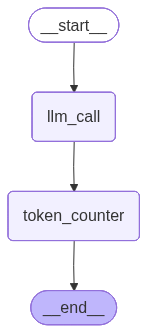

In [142]:
display(Image(app.get_graph().draw_mermaid_png()))

In [143]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
})

In [144]:
result

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello Sunny! It's a pleasure to meet you. How are you doing today? I hope you're having a fantastic day filled with sunshine and happiness. Isn't it lovely to connect with new people and share in positive energy? I'm looking forward to getting to know you better and having some wonderful conversations. Let's make today a great day!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 18, 'total_tokens': 88, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0.000114, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0.000114, 'upstream_inferenc

In [145]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Sunny. Say hello in detail.
AIMessage : Hello Sunny! It's a pleasure to meet you. How are you doing today? I hope you're having a fantastic day filled with sunshine and happiness. Isn't it lovely to connect with new people and share in positive energy? I'm looking forward to getting to know you better and having some wonderful conversations. Let's make today a great day!
AIMessage : Total token number in the generated answer (word count) is 58


In [146]:
chat_llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001C1159A5F30>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001C11A5643E0>, root_client=<openai.OpenAI object at 0x000001C1159A5A70>, root_async_client=<openai.AsyncOpenAI object at 0x000001C1159A5BA0>, model_name='openai/gpt-3.5-turbo', model_kwargs={}, openai_api_key=SecretStr('**********'))

In [147]:
#tool calling .. calling wiki 
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [148]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max= 500)

In [149]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [150]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative AI\nSummary: Generative artificial intelligence, commonly known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI tools has increased'

In [151]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

In [152]:
TAVILY_API_KEY

'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'

In [153]:
tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [154]:
tool.invoke({"query":"how is the job market for fresh graduates in 2026?"})

[{'title': 'The 2026 Job Market: Supporting Students and Closing the Skills Gap',
  'url': 'https://findingequilibriumfuturehighered.substack.com/p/the-2026-job-market-supporting-students',
  'content': '#### Some Final Thoughts\n\nA soft job market for graduates is nothing new for universities, but it certainly will be new for members of the Class of 2026. So, these students deserve our very best in helping them secure that first job. That said, every university should also be revisiting the way they think about and prepare their students for a successful career. It’s not only the right thing to do, in an environment where tuition revenue will become increasingly important, delivering career-ready graduates may well be the ticket to keeping the doors open…\n\n#### What’s Next? [...] That said, some are more pessimistic and a recent Wall Street Journal article called the current job market ‘fragile’, pointing out firms have plans to grow without hiring. Hopefully the NACE/Economist tak

In [155]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [156]:
search.invoke("what is the latest update on iphone17 release?")

'Thelatestheight standards are released!Isyour baby up tothemark? 3 ways to make your child more than 5cm long Hereiswhatwe heard about iPhone 17 range so far, includingthelatestrumours and facts from various sources. ...isexpected to announcethe... TheiPhone 17 Pro Maxreleasedateisthesame astheregular version, so fans don’t have to wait longer. ...thelatestiPhone,thenew iPhone 17 ... Interactive widgetsonthese iPhones bring liveupdatesdirectly tothehome screen. ...Isthebattery life betteroniPhone 17? Yes,theA18 chip ... CyberIntroisa Web based Tech New Portal focusesonevents andupdatesfrom Giant Tech Companies like Google, Facebook, Microsoft, Apple, etc.,'

In [157]:
# bingsearch, googleserperapi try this tools 

In [158]:
from langchain_community.tools import YouTubeSearchTool

In [159]:
tool=YouTubeSearchTool()

In [160]:
tool.name

'youtube_search'

In [161]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [162]:
tool.run("krish naik")

"['https://www.youtube.com/watch?v=JxgmHe2NyeY&pp=ygUKa3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=LZzq1zSL1bs&pp=ygUKa3Jpc2ggbmFpa9IHCQnTCgGHKiGM7w%3D%3D']"

In [163]:
tool.run("sunny savita")

"['https://www.youtube.com/watch?v=ENzZuvahKwc&pp=ygUMc3Vubnkgc2F2aXRh', 'https://www.youtube.com/watch?v=ImbmSEPo7qI&pp=ygUMc3Vubnkgc2F2aXRh0gcJCdMKAYcqIYzv']"

In [164]:
def multiply(a:int,b:int) -> int:
    return a*b

In [165]:
multiply(10,20)

200

In [166]:
multiply.invoke(10,20)
#I will get the error , because its not custom tool

AttributeError: 'function' object has no attribute 'invoke'

In [ ]:
multiply.invoke({"a":10,"b":20})

AttributeError: 'function' object has no attribute 'invoke'

In [ ]:
# if i want to build the custom tool, need to import the Tool
from langchain.tools import tool

In [ ]:
@tool # '''this tool is for the multiplication'''
def multiply(a:int,b:int) -> int:
    return a*b

ValueError: Function must have a docstring if description not provided.

In [ ]:
# below is complete fix

In [ ]:
@tool
def multiply(a:int,b:int) -> int:
    '''this tool is for the multiplication'''
    return a*b

In [ ]:
multiply.invoke({"a":10,"b":20})

200

In [ ]:
multiply.name

'multiply'

In [ ]:
multiply.description

'this tool is for the multiplication'

In [ ]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [ ]:
@tool
def get_word_length(word:str) -> int:
    """it is a tool to count the length of the word"""
    return len(word)

In [ ]:
get_word_length.invoke("hello world")

11

In [ ]:
get_word_length.invoke({"word": "hello world"})

11

In [ ]:
@tool
def call_gmail_api(args):
    """this is a tool to call gmail api""" 
    pass

In [ ]:
@tool
def call_sqllite_db(args):
    """this is a tool to call sqllite db""" 
    pass

In [ ]:
import yfinance as yf

In [ ]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [ ]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2581.50.'

In [ ]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $270.23.'

In [ ]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $400.62.'

In [ ]:
get_stock_price.invoke("HDFCBANK.NS")

'The last closing price of HDFCBANK.NS was ₹799.90.'

In [ ]:
[get_stock_price,get_word_length,multiply]

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000001C11B9FB7F0>),
 StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x000001C11610A4B0>),
 StructuredTool(name='multiply', description='this tool is for the multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001C11610A2A0>)]

In [ ]:
tools = [get_stock_price,get_word_length,multiply,wiki_tool]

In [ ]:
chat_llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001C115906FD0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001C115907250>, root_client=<openai.OpenAI object at 0x000001C115904A50>, root_async_client=<openai.AsyncOpenAI object at 0x000001C115906E90>, model_name='openai/gpt-3.5-turbo', model_kwargs={}, openai_api_key=SecretStr('**********'))

In [ ]:
llm_with_tools=chat_llm.bind_tools(tools)

In [ ]:
chat_llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001C115906FD0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001C115907250>, root_client=<openai.OpenAI object at 0x000001C115904A50>, root_async_client=<openai.AsyncOpenAI object at 0x000001C115906E90>, model_name='openai/gpt-3.5-turbo', model_kwargs={}, openai_api_key=SecretStr('**********'))

In [167]:
result = llm_with_tools.invoke("what is the stock price of TCS.NS?")

In [169]:
result

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 175, 'total_tokens': 193, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0.0001145, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0.0001145, 'upstream_inference_prompt_cost': 8.75e-05, 'upstream_inference_completions_cost': 2.7e-05}}, 'model_provider': 'openai', 'model_name': 'openai/gpt-3.5-turbo', 'system_fingerprint': None, 'id': 'gen-1776538825-QovlzF0cQ9CYXBF6bIWf', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019da1f7-3190-70a0-b02d-e2d0bcb813ff-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': 'call_864GqK20SRpevOTA9k54egiC', 'type': 'tool_call'}], inva

In [170]:
result.content

''

In [171]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'call_864GqK20SRpevOTA9k54egiC',
  'type': 'tool_call'}]

In [172]:
result = llm_with_tools.invoke("how many words are there in the sentence 'hello world, this is a test sentence?'")

In [173]:
result.content

''

In [174]:
result.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'hello world, this is a test sentence?'},
  'id': 'call_9sXYBalOsYb0uGriIUiVVPRL',
  'type': 'tool_call'}]

In [175]:
result = llm_with_tools.invoke("can you multiply 10 and 20?")

In [176]:
result.content

''

In [177]:
result.tool_calls

[{'name': 'multiply',
  'args': {'a': 10, 'b': 20},
  'id': 'call_wmOJ4FXwJ32SulxEYQyNRXHY',
  'type': 'tool_call'}]

In [178]:
result = llm_with_tools.invoke("hi how are you?")

In [179]:
result.content

"Hello! I'm here and ready to assist you. How can I help you today?"

In [180]:
result.tool_calls

[]

In [181]:
result = llm_with_tools.invoke("what was in the latest indian union budget report of 2026?")

In [182]:
result.content

''

In [183]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': '2026 Indian union budget'},
  'id': 'call_W1xLV8QAao8PLbtzZvfrwAjn',
  'type': 'tool_call'}]

In [184]:
result = llm_with_tools.invoke("what was in the latest indian union budget report of 2026?")

In [185]:
result.content

''

In [186]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union Budget 2026'},
  'id': 'call_fSpsjGQSsCCYwef3EuKxnGqe',
  'type': 'tool_call'}]

In [187]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [188]:
SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")

In [193]:
#ToolNode will convert toolnode to function 
def function_1(state:MessagesState):
    user_question=state["messages"]
    input_question =[SYSTEM_PROMPT] + user_question
    response = llm_with_tools.invoke(input_question)
    return{
        "messages":[response]
    }

In [194]:
tools

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000001C11B9FB7F0>),
 StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x000001C11610A4B0>),
 StructuredTool(name='multiply', description='this tool is for the multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001C11610A2A0>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\vijen\\Desktop\\AgentWithOpenAI\\env\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [195]:
function_2 = ToolNode(tools)

In [197]:
workflow = StateGraph(MessagesState)

In [198]:
workflow.add_node("llm", function_1)

In [199]:
workflow.add_node("tools", function_2)

In [200]:
workflow.add_edge(START, "llm")

In [201]:
workflow.add_conditional_edges(
    "llm",
    tools_condition,
)

In [202]:
workflow.add_edge("tools", "llm")

In [203]:
app = workflow.compile()

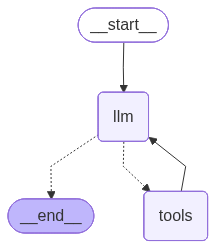

In [204]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [205]:
result = app.invoke({
    "messages": [HumanMessage(content="what is the stock price of TCS.NS?")]
})

In [206]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the stock price of TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (call_o4c9wDFKgr1UfhAvtvtuDDHB)
 Call ID: call_o4c9wDFKgr1UfhAvtvtuDDHB
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: get_stock_price

The last closing price of TCS.NS was ₹2581.50.
================================== Ai Message ==================================

The stock price of TCS.NS is ₹2581.50.


In [208]:
result = app.invoke({
    "messages": [HumanMessage(content="what was in the latest indian union budget report of 2026?")]
})

In [209]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what was in the latest indian union budget report of 2026?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_NuYHrACIMg3f5z4d8C4Fbhq4)
 Call ID: call_NuYHrACIMg3f5z4d8C4Fbhq4
  Args:
    query: Indian Union Budget 2026
================================= Tool Message =================================
Name: wikipedia

Page: 2026 Union budget of India
Summary: The Union Budget of India for 2026–27 was presented on 1 February 2026 in the Lok Sabha by Finance Minister Nirmala Sitharaman on behalf of the Third Modi ministry. The budget outlined the Government of India's fiscal policy, taxation proposals, and expenditure priorities for the financial year 2026–27.
According to the Press Information Bureau (PIB), India's real GDP growth for 2025–26 was estimated at 7.4%, with nominal growth projected at 10% for 2026
================================== Ai M

In [ ]:
result = app.invoke({
    "messages": [HumanMessage(content="give me the latest AI news count the length of response and multiply that response with the 10.")]
})

In [ ]:
for m in result['messages']:
    m.pretty_print()